In [1]:
# === RandomizedSearchCV untuk Random Forest (fokus: Recall Churn) ===
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, precision_recall_curve
)

In [2]:
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [3]:
# 1) Estimator baseline (param lain dicari via random search)
rf = RandomForestClassifier(
    n_jobs=-1,          # gunakan semua core (tidak mempengaruhi hasil, hanya waktu training)
    random_state=42
)

In [4]:
# 2) Ruang pencarian hyperparameter
#   - n_estimators: banyaknya pohon (lebih banyak → stabil, tapi lebih lambat)
#   - max_depth: batasi kedalaman pohon untuk cegah overfit
#   - min_samples_split / min_samples_leaf: kontrol granularitas split & daun (naikkan → lebih “hemat”)
#   - max_features: jumlah fitur per split ('sqrt' umum untuk klasifikasi)
#   - class_weight: atasi imbalance (balanced / balanced_subsample)
#   - bootstrap: sampling dengan pengembalian (bagging klasik)
#   - criterion: fungsi impurity
#   - ccp_alpha: pruning cost-complexity (sedikit > 0 untuk kurangi overfit)
param_dist = {
    "n_estimators": randint(200, 801),
    "max_depth": randint(5, 31),
    "min_samples_split": randint(2, 51),
    "min_samples_leaf": randint(1, 21),
    "max_features": ["sqrt", "log2"],     # <- jangan None
    "class_weight": ["balanced", "balanced_subsample"],
    "bootstrap": [True],                  # <- wajib True
    "criterion": ["gini", "entropy", "log_loss"],
    "ccp_alpha": uniform(0.0, 0.01),
}
# Catatan: tidak memasukkan 'max_samples' agar aman saat bootstrap=False.

In [5]:
# 3) CV stratified (penting untuk data imbalanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [6]:
# 4) Random Search: optimasi berdasarkan RECALL (tapi tetap simpan metrik lain)
scoring = {
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}
rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=80,                 # boleh 60–150, sesuaikan waktu
    scoring=scoring,
    refit="recall",            # pilih model dengan recall CV terbaik
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [7]:
# 5) Jalankan pencarian
rs_rf.fit(X_train, y_train.ravel())

print("Best params (berdasarkan Recall CV):")
print(rs_rf.best_params_)
print("\nSkor CV rata-rata pada best index:")
best_idx = rs_rf.best_index_
for k in scoring.keys():
    print(f"{k:>9}: {rs_rf.cv_results_[f'mean_test_{k}'][best_idx]:.4f}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params (berdasarkan Recall CV):
{'bootstrap': True, 'ccp_alpha': np.float64(0.006963042728397884), 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 17, 'min_samples_split': 50, 'n_estimators': 201}

Skor CV rata-rata pada best index:
   recall: 0.8181
precision: 0.4952
       f1: 0.6168
  roc_auc: 0.8356
 accuracy: 0.7298


In [8]:
# 6) Evaluasi di test set (threshold default)
best_rf = rs_rf.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC (Test): {roc_auc_score(y_test, y_proba):.4f}")


Confusion Matrix (Test):
[[701 332]
 [ 79 295]]

Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.90      0.68      0.77      1033
       Churn       0.47      0.79      0.59       374

    accuracy                           0.71      1407
   macro avg       0.68      0.73      0.68      1407
weighted avg       0.78      0.71      0.72      1407

ROC-AUC (Test): 0.8216


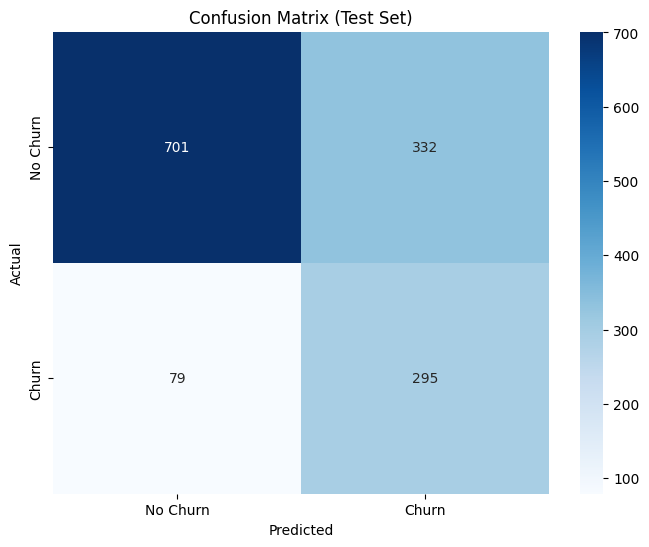

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# 7) (Opsional) Tuning threshold pasca-model untuk kontrol FP vs FN
prec, rec, thr = precision_recall_curve(y_test, y_proba)
mask = rec >= 0.75                # contoh target recall minimum
if np.any(mask):
    best_i = np.argmax(prec[mask])
    thr_opt = thr[mask][best_i]
    y_pred_thr = (y_proba >= thr_opt).astype(int)
    print(f"\nThreshold optimal (recall>=0.75): {thr_opt:.4f}")
    print(confusion_matrix(y_test, y_pred_thr))
    print(classification_report(y_test, y_pred_thr, target_names=["No Churn", "Churn"]))
